## Phase stability

In [1]:
import os
import warnings

import numpy as np
from ase import build
from ase.calculators import eam
from matplotlib import pyplot as plt
from pyiron_workflow_atomistics import engine as engine_mod

from demonstrators import gibbs_nodes, phase_nodes

# Pb potential: https://www.ctcms.nist.gov/potentials/entry/2018--Wang-K-Zhu-W-Xiang-M-et-al--Pb-II/
WORKING_DIR = "phase_diagnostic"
engine = engine_mod.ASEEngine(
    EngineInput=engine_mod.CalcInputStatic(),
    calculator=eam.EAM(potential="Pb_II_Wang_2018.eam.alloy", form="alloy"),
    working_directory=WORKING_DIR,
    record_interval=100,
)
temperatures = np.linspace(0.0, 600.0, 7)


def quiet_phonopy():
    """Silence phonopy's chatter while leaving `gibbs_nodes`' warnings audible.

    `warnings.simplefilter("ignore")` would also hide this project's own
    `UserWarning`s -- shape minimisation falling back to the sampled argmin, a
    pressure that failed to converge, a dG that crosses zero more than once.
    Those are precisely the things worth hearing, so only the known-harmless
    noise is filtered: phonopy's deprecated `get_*_dict()` accessors, its
    `primitive_matrix` auto-resolution notice, and its point-group mesh
    fallback notice.
    """
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings("ignore", message=".*primitive_matrix.*")
    warnings.filterwarnings("ignore", message=".*point group.*")

In [2]:
COVERA = np.sqrt(8.0 / 3.0)
FCC_V_57GPA = 20.7
HCP_V_57GPA = 20.6
HCP_V_84GPA = 19.1
BCC_V_84GPA = 18.9


def fcc_at(volume_per_atom):
    return build.bulk("Pb", "fcc", a=(4.0 * volume_per_atom) ** (1 / 3), cubic=True)


def bcc_at(volume_per_atom):
    return build.bulk("Pb", "bcc", a=(2.0 * volume_per_atom) ** (1 / 3), cubic=True)


def hcp_at(volume_per_atom, covera=COVERA):
    # Hexagonal, not orthorhombic: same phonons to 0.03 meV/atom in 200 atoms
    # instead of 240, and it keeps the cell's hexagonal point group so phonopy
    # does not warn. `apply_strains`' c_over_a mode scales the cell rows by
    # (g, g, f), which is exactly the c/a strain on a hexagonal cell.
    a = (4.0 * volume_per_atom / (np.sqrt(3.0) * covera)) ** (1 / 3)
    return build.bulk("Pb", "hcp", a=a, covera=covera)


# Seed volumes used below -- 20.7 (fcc), 20.6 (hcp near 57 GPa), 19.1 (hcp near
# 84 GPa), 18.9 (bcc) A^3/atom -- are the static-enthalpy minima tabulated in
# `.claude/reports/2026-08-20-04:44-phonon-convergence-diagnostic.md`
# (finding 2): V* solving -dE/dV = P on a dense volume scan at the relevant
# transition pressure.
#
# One seed per sweep rather than one per pressure is deliberate.
# `gibbs_nodes.supercell_repetitions` is evaluated once from the seed and then
# pinned for the whole run; a per-pressure seed could cross a `ceil` boundary
# partway through a sweep, silently change the force-constant cutoff mid-sweep,
# and break the commensurability that the shared target length exists to
# provide. The self-consistent loop moves each pressure onto its own volume
# regardless of where it starts.

## Phonon settings

Two settings dominate the error budget for a phase comparison, and both are
about making the *difference* between phases trustworthy rather than making
either phase individually accurate.

**Force-constant supercells must share a real-space extent.** Truncating force
constants at the supercell boundary is an error that only cancels in ΔG when
both phases are truncated at the same distance. Fixed repetitions do not
achieve this: at 57 GPa a `(2,2,2)` fcc cell spans 8.6 Å while a `(4,2,2)` hcp
cell spans 12.1 Å, and ΔF_vib(fcc − hcp) comes out 0.71 meV/atom away from its
converged value — **with the opposite sign**. That is about 0.9 GPa of
transition pressure. `gibbs_nodes.supercell_repetitions` picks
`n_i = ceil(L / |a_i|)` from a shared target length instead.

**The displacement distance must sit on hcp's plateau, not fcc's.** fcc's
F_vib is flat to within 0.07 meV/atom all the way out to d = 0.08 Å; hcp moves
2.1 meV/atom over the same range, because its lower site symmetry generates
fewer symmetry-equivalent displacements and the O(d²) anharmonic contamination
survives. The plateau common to every phase here ends around d = 0.02 Å, so we
use **d = 0.01 Å** — the same cost, no knee.

The cell below reproduces both scans so the choices are shown, not asserted.

In [3]:
# Absolute: `_vibrational_free_energy` joins this onto the engine's own
# `working_directory`, so a relative path would land in phase_demo/phase_demo/.
CONVERGENCE_DIR = os.path.abspath(f"{WORKING_DIR}/convergence")


def vib_free_energy(structure, reps, displacement, tag):
    return gibbs_nodes._vibrational_free_energy(
        structure,
        engine,
        temperatures=temperatures,
        fc2_supercell_matrix=np.diag(reps),
        displacement_distance=displacement,
        is_plusminus="auto",
        working_directory=CONVERGENCE_DIR,
        tag=tag,
    )


def scan_supercell_lengths(name, structure, lengths, displacement=0.01):
    rows = []
    seen = set()
    for length in lengths:
        reps = gibbs_nodes.supercell_repetitions(structure, target_length=length)
        if reps in seen:
            continue
        seen.add(reps)
        # `name` is in the tag because fcc and hcp share target lengths: without
        # it they collide at L=7 and L=18 and the second phase silently reuses
        # the first phase's directory.
        free_energy = vib_free_energy(
            structure, reps, displacement, f"{name}_L{length:.0f}_d{displacement:.3f}"
        )
        rows.append((length, reps, free_energy[-1]))
    return rows


def scan_displacements(name, structure, displacements, length=15.0):
    reps = gibbs_nodes.supercell_repetitions(structure, target_length=length)
    return [
        (
            displacement,
            reps,
            vib_free_energy(
                structure,
                reps,
                displacement,
                f"{name}_L{length:.0f}_d{displacement:.3f}",
            )[-1],
        )
        for displacement in displacements
    ]


def print_scan(title, first_label, first_format, rows):
    print(f"\n{title}")
    print(f"{first_label:>7} {'reps':>12} {'F(600K)':>13}")
    for first, reps, free_energy in rows:
        print(f"{first_format.format(first):>7} {str(reps):>12} {free_energy:13.6f}")


with warnings.catch_warnings():
    quiet_phonopy()
    lengths = [7, 9, 11, 13, 15, 18]
    fcc_length_rows = scan_supercell_lengths("fcc", fcc_at(20.7), lengths)
    hcp_length_rows = scan_supercell_lengths("hcp", hcp_at(20.6), lengths)
    fcc_displacement_rows = scan_displacements(
        "fcc", fcc_at(FCC_V_57GPA), [0.005, 0.01, 0.02, 0.03, 0.05]
    )
    hcp_displacement_rows = scan_displacements(
        "hcp", hcp_at(HCP_V_57GPA), [0.005, 0.01, 0.02, 0.03, 0.05]
    )

# fcc and hcp both dedupe to 4 rows here, but at different target lengths --
# (7, 9, 15, 18) for fcc vs (7, 11, 13, 18) for hcp, since each phase's cell
# has a different lattice parameter. Zipping by position would silently pair
# rows computed at different L, so the two tables are printed separately
# instead.
print_scan("fcc, supercell length", "L (A)", "{:.0f}", fcc_length_rows)
print_scan("hcp, supercell length", "L (A)", "{:.0f}", hcp_length_rows)

# The displacement scan is run at a single converged length (15 A) for both
# phases, so what varies between the two tables is only the site symmetry.
print_scan("fcc, displacement at L=15 A", "d (A)", "{:.3f}", fcc_displacement_rows)
print_scan("hcp, displacement at L=15 A", "d (A)", "{:.3f}", hcp_displacement_rows)


fcc, supercell length
  L (A)         reps       F(600K)
      7    (2, 2, 2)     -0.231847
      9    (3, 3, 3)     -0.232593
     15    (4, 4, 4)     -0.232647
     18    (5, 5, 5)     -0.232705

hcp, supercell length
  L (A)         reps       F(600K)
      7    (3, 3, 2)     -0.231728
     11    (4, 4, 3)     -0.232388
     13    (5, 5, 3)     -0.232348
     18    (6, 6, 4)     -0.232355

fcc, displacement at L=15 A
  d (A)         reps       F(600K)
  0.005    (4, 4, 4)     -0.232644
  0.010    (4, 4, 4)     -0.232647
  0.020    (4, 4, 4)     -0.232936
  0.030    (4, 4, 4)     -0.234650
  0.050    (4, 4, 4)     -0.237597

hcp, displacement at L=15 A
  d (A)         reps       F(600K)
  0.005    (5, 5, 3)     -0.232346
  0.010    (5, 5, 3)     -0.232348
  0.020    (5, 5, 3)     -0.232353
  0.030    (5, 5, 3)     -0.232363
  0.050    (5, 5, 3)     -0.232889


## Does the volume fit change the answer?

`fit_degree` and the width of the volume window are free parameters, and a
free parameter that nobody measures is an assumption. The cell below varies
both — degree 2, 3 and 4, at the default ±0.04 window and a narrow ±0.015 one —
and reports the resulting ΔG(fcc − hcp) at 57 GPa, converted to an implied
shift in the transition pressure at 1.24 GPa per meV/atom (the static-enthalpy
conversion from finding 2 of the phonon-convergence diagnostic).

This is the cell that keeps the fit honest. `converged=True` speaks only about
the *drift between iterations*; it says nothing about the residual bias shared
by every iteration, and a degree-3 fit over ±0.04 carries 0.8–2.1 meV/atom of
it. Read `fit residual` in the last column alongside the ΔG: if the spread
across this table is comparable to the ΔG being resolved, the phase boundary is
a property of the fit and not of the potential.

It is deliberately cheap — a 10 Å supercell target and two temperatures — so it
is a sensitivity probe, not a production number.

In [4]:
FIT_WINDOWS = [(-0.04, 0.04), (-0.015, 0.015)]
FIT_DEGREES = [2, 3, 4]
GPA_PER_MEV_FCC_HCP = 1.24  # finding 2 of the phonon-convergence diagnostic


def gibbs_at_57(structure, shape_mode, fit_degree, window, tag):
    return gibbs_nodes.gibbs_at_pressure(
        structure,
        engine,
        pressure=57.0,
        temperatures=(0.0, 300.0),
        supercell_target_length=10.0,
        strain_range=window,
        fit_degree=fit_degree,
        shape_mode=shape_mode,
        working_directory=os.path.abspath(WORKING_DIR),
        tag=f"fit_sensitivity/{tag}",
    )


sensitivity_rows = []
with warnings.catch_warnings():
    quiet_phonopy()
    for window in FIT_WINDOWS:
        for fit_degree in FIT_DEGREES:
            tag = f"deg{fit_degree}_w{window[1]:.3f}"
            fcc_result = gibbs_at_57(
                fcc_at(20.7), None, fit_degree, window, f"fcc_{tag}"
            )
            hcp_result = gibbs_at_57(
                hcp_at(20.6),
                phase_nodes.StrainMode.C_OVER_A,
                fit_degree,
                window,
                f"hcp_{tag}",
            )
            sensitivity_rows.append((window, fit_degree, fcc_result, hcp_result))

# Every row is compared against the shipped defaults -- degree 3 at the default
# window -- so the shift column reads as "what this choice would have done to
# the answer we actually report".
reference = next(
    (fcc.gibbs - hcp.gibbs) * 1000.0
    for window, fit_degree, fcc, hcp in sensitivity_rows
    if fit_degree == 3 and window == FIT_WINDOWS[0]
)
header = (
    f"{'window':>16} {'deg':>4} {'dG 0K':>9} {'dG 300K':>9} "
    f"{'shift 0K':>10} {'shift 300K':>11} {'resid':>9} {'conv':>6}"
)
print(header)
print("-" * len(header))
for window, fit_degree, fcc_result, hcp_result in sensitivity_rows:
    delta = (fcc_result.gibbs - hcp_result.gibbs) * 1000.0
    shift = (delta - reference) * GPA_PER_MEV_FCC_HCP
    residual = max(fcc_result.fit_residual, hcp_result.fit_residual) * 1000.0
    converged = fcc_result.converged and hcp_result.converged
    print(
        f"{str(window):>16} {fit_degree:>4} {delta[0]:9.3f} {delta[1]:9.3f} "
        f"{shift[0]:10.3f} {shift[1]:11.3f} {residual:9.3f} {str(converged):>6}"
    )
print("\ndG and resid in meV/atom; shift in GPa, relative to degree 3 at "
      f"{FIT_WINDOWS[0]}.")

          window  deg     dG 0K   dG 300K   shift 0K  shift 300K     resid   conv
---------------------------------------------------------------------------------
   (-0.04, 0.04)    2    -0.711    -3.688     -0.094       0.959     2.646   True
   (-0.04, 0.04)    3    -0.635    -4.461      0.000       0.000     0.930   True
   (-0.04, 0.04)    4    -0.639    -5.080     -0.004      -0.768     0.894   True
 (-0.015, 0.015)    2    -0.712    -3.604     -0.095       1.062     2.584   True
 (-0.015, 0.015)    3    -0.635    -4.418      0.000       0.053     0.905   True
 (-0.015, 0.015)    4    -0.634    -5.055      0.001      -0.737     0.857   True

dG and resid in meV/atom; shift in GPa, relative to degree 3 at (-0.04, 0.04).


In [5]:
PRESSURES_LO = np.array([51.0, 54.0, 57.0, 60.0, 63.0])

with warnings.catch_warnings():
    quiet_phonopy()
    fcc_sweep = gibbs_nodes.gibbs_over_pressures(
        fcc_at(20.7),
        engine,
        PRESSURES_LO,
        temperatures=temperatures,
        shape_mode=None,
        working_directory=WORKING_DIR,
        tag="fcc_lo",
    )
    hcp_sweep_lo = gibbs_nodes.gibbs_over_pressures(
        hcp_at(20.6),
        engine,
        PRESSURES_LO,
        temperatures=temperatures,
        shape_mode=phase_nodes.StrainMode.C_OVER_A,
        working_directory=WORKING_DIR,
        tag="hcp_lo",
    )

for name, sweep in (("fcc", fcc_sweep), ("hcp", hcp_sweep_lo)):
    drift = [f"{r.gibbs_drift:.1e}" for r in sweep.results]
    residual = [f"{r.fit_residual:.1e}" for r in sweep.results]
    fell_back = sum(r.shape_fell_back_count for r in sweep.results)
    print(f"{name}: converged={[r.converged for r in sweep.results]}")
    print(f"     drift (eV/atom):        {drift}")
    # `fit_residual` is the honest error bar on `gibbs`: `converged` only says
    # the loop stopped moving, and until the window narrows it can stop moving
    # with the fit bias fully intact. Compare it against the ~0.5 meV/atom dG
    # being plotted below.
    print(f"     fit residual (eV/atom): {residual}")
    print(f"     shape fallbacks: {fell_back}")

/Users/liamhuber/dev/pyiron/draft-demonstrators/demonstrators/gibbs_nodes.py:876: UserWarning: Gibbs energy did not converge at 51.0 GPa after 8 iterations: drift 2.640e-04 eV/atom vs tolerance 1.000e-04. Returning the last iteration. Raise `max_iterations`, or widen `strain_range` if the optimal volumes are drifting rather than settling.
  pressure_array = np.asarray(pressures, dtype=float)
/Users/liamhuber/dev/pyiron/draft-demonstrators/demonstrators/gibbs_nodes.py:876: UserWarning: Gibbs energy did not converge at 54.0 GPa after 8 iterations: drift 2.993e-04 eV/atom vs tolerance 1.000e-04. Returning the last iteration. Raise `max_iterations`, or widen `strain_range` if the optimal volumes are drifting rather than settling.
  pressure_array = np.asarray(pressures, dtype=float)
/Users/liamhuber/dev/pyiron/draft-demonstrators/demonstrators/gibbs_nodes.py:876: UserWarning: Gibbs energy did not converge at 57.0 GPa after 8 iterations: drift 3.970e-04 eV/atom vs tolerance 1.000e-04. Retur

fcc: converged=[False, False, False, True, True]
     drift (eV/atom):        ['2.6e-04', '3.0e-04', '4.0e-04', '3.3e-05', '7.1e-05']
     fit residual (eV/atom): ['3.6e-03', '3.2e-03', '1.5e-03', '1.9e-03', '3.6e-04']
     shape fallbacks: 0
hcp: converged=[True, True, True, True, True]
     drift (eV/atom):        ['5.7e-05', '3.1e-06', '8.6e-05', '4.1e-05', '8.2e-05']
     fit residual (eV/atom): ['1.1e-03', '9.2e-04', '7.8e-04', '8.9e-05', '1.9e-04']
     shape fallbacks: 0


In [6]:
PRESSURES_HI = np.array([78.0, 81.0, 84.0, 87.0, 90.0])

with warnings.catch_warnings():
    quiet_phonopy()
    hcp_sweep_hi = gibbs_nodes.gibbs_over_pressures(
        hcp_at(19.1),
        engine,
        PRESSURES_HI,
        temperatures=temperatures,
        shape_mode=phase_nodes.StrainMode.C_OVER_A,
        working_directory=WORKING_DIR,
        tag="hcp_hi",
    )
    bcc_sweep = gibbs_nodes.gibbs_over_pressures(
        bcc_at(18.9),
        engine,
        PRESSURES_HI,
        temperatures=temperatures,
        shape_mode=None,
        working_directory=WORKING_DIR,
        tag="bcc_hi",
    )

for name, sweep in (("hcp", hcp_sweep_hi), ("bcc", bcc_sweep)):
    drift = [f"{r.gibbs_drift:.1e}" for r in sweep.results]
    residual = [f"{r.fit_residual:.1e}" for r in sweep.results]
    fell_back = sum(r.shape_fell_back_count for r in sweep.results)
    print(f"{name}: converged={[r.converged for r in sweep.results]}")
    print(f"     drift (eV/atom):        {drift}")
    # `fit_residual` is the honest error bar on `gibbs`: `converged` only says
    # the loop stopped moving, and until the window narrows it can stop moving
    # with the fit bias fully intact. Compare it against the ~0.5 meV/atom dG
    # being plotted below.
    print(f"     fit residual (eV/atom): {residual}")
    print(f"     shape fallbacks: {fell_back}")

hcp: converged=[True, True, True, True, True]
     drift (eV/atom):        ['1.4e-05', '7.4e-05', '7.9e-05', '9.0e-05', '6.6e-05']
     fit residual (eV/atom): ['8.7e-04', '1.0e-03', '1.1e-03', '1.3e-03', '1.2e-03']
     shape fallbacks: 0
bcc: converged=[True, True, True, True, True]
     drift (eV/atom):        ['4.2e-05', '8.4e-07', '4.0e-06', '8.9e-05', '4.6e-05']
     fit residual (eV/atom): ['2.4e-06', '1.8e-06', '1.8e-06', '2.1e-04', '2.2e-04']
     shape fallbacks: 0


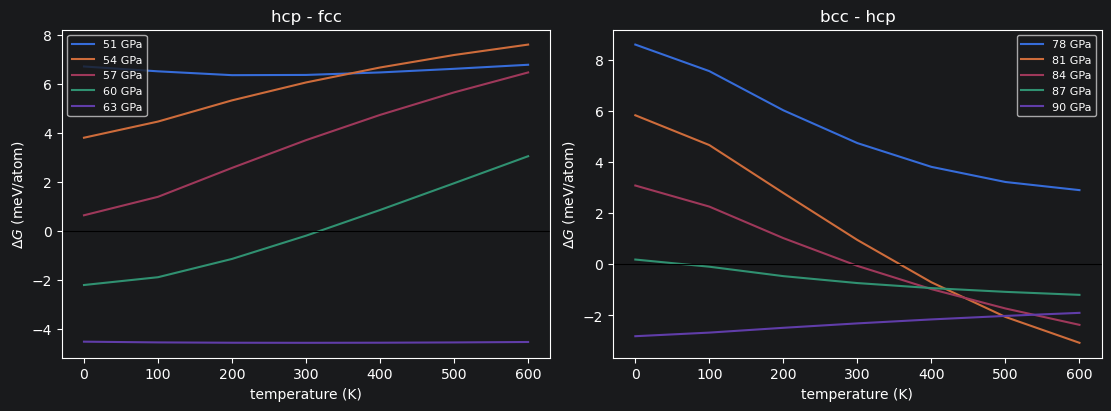

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for index, pressure in enumerate(PRESSURES_LO):
    axes[0].plot(
        temperatures,
        (hcp_sweep_lo.gibbs[:, index] - fcc_sweep.gibbs[:, index]) * 1000.0,
        label=f"{pressure:.0f} GPa",
    )
axes[0].set_title("hcp - fcc")
for index, pressure in enumerate(PRESSURES_HI):
    axes[1].plot(
        temperatures,
        (bcc_sweep.gibbs[:, index] - hcp_sweep_hi.gibbs[:, index]) * 1000.0,
        label=f"{pressure:.0f} GPa",
    )
axes[1].set_title("bcc - hcp")
for axis in axes:
    axis.axhline(0.0, color="k", lw=0.8)
    axis.set_xlabel("temperature (K)")
    axis.set_ylabel(r"$\Delta G$ (meV/atom)")
    axis.legend(fontsize=8)
plt.show()

fcc/hcp boundary (GPa): [57.68 58.28 59.08 59.85 60.48 60.9  61.21]
hcp/bcc boundary (GPa): [87.18 86.87 86.06 83.8  80.53 79.83 79.46]


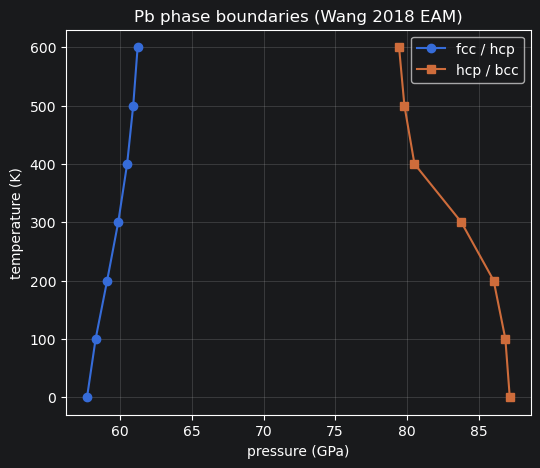

In [8]:
boundary_lo = gibbs_nodes.phase_boundary(fcc_sweep, hcp_sweep_lo)
boundary_hi = gibbs_nodes.phase_boundary(hcp_sweep_hi, bcc_sweep)
print("fcc/hcp boundary (GPa):", np.round(boundary_lo, 2))
print("hcp/bcc boundary (GPa):", np.round(boundary_hi, 2))

plt.figure(figsize=(6, 5))
plt.plot(boundary_lo, temperatures, "o-", label="fcc / hcp")
plt.plot(boundary_hi, temperatures, "s-", label="hcp / bcc")
plt.xlabel("pressure (GPa)")
plt.ylabel("temperature (K)")
plt.title("Pb phase boundaries (Wang 2018 EAM)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
with warnings.catch_warnings():
    quiet_phonopy()
    hcp_static = gibbs_nodes.gibbs_at_pressure(
        hcp_at(20.6),
        engine,
        pressure=57.0,
        temperatures=temperatures,
        shape_mode=phase_nodes.StrainMode.C_OVER_A,
        shape_objective="static",
        working_directory=WORKING_DIR,
        tag="hcp_quasistatic",
    )

free_energy_result = hcp_sweep_lo.results[2]  # 57 GPa
difference = (hcp_static.gibbs - free_energy_result.gibbs) * 1000.0
print(f"{'T (K)':>7} {'G static':>12} {'G free-energy':>14} {'diff (meV)':>11}")
for index, temperature in enumerate(temperatures):
    print(
        f"{temperature:7.0f} {hcp_static.gibbs[index]:12.6f} "
        f"{free_energy_result.gibbs[index]:14.6f} {difference[index]:11.4f}"
    )
print(
    f"\nc/a strain at 0 K vs 600 K, free-energy optimised: "
    f"{free_energy_result.optimal_shape_strains[0]:.5f} -> "
    f"{free_energy_result.optimal_shape_strains[-1]:.5f}"
)

  T (K)     G static  G free-energy  diff (meV)
      0     6.461184       6.461390     -0.2063
    100     6.452385       6.452825     -0.4402
    200     6.422549       6.423418     -0.8687
    300     6.379848       6.381208     -1.3607
    400     6.328462       6.330348     -1.8866
    500     6.270544       6.272970     -2.4256
    600     6.207401       6.210365     -2.9642

c/a strain at 0 K vs 600 K, free-energy optimised: -0.00040 -> 0.00053


## What changed, and why the old charts wobbled

At the transition pressure ΔG ≈ 0 by construction, so the plotted curve spans
only about 0.5 meV/atom over 0–600 K. The force-constant supercell artefact
alone was 0.7 meV/atom. **The plotted quantity was smaller than the numerical
noise in it** — which is why the physics looked right (the transition pressure
only moved about 1 GPa) while the charts looked alarming.

Three changes fix that:

1. Force-constant supercells sized to a shared real-space target length, so
   truncation error cancels in ΔG.
2. `displacement_distance = 0.01 Å`, on the plateau for every phase here.
3. A self-consistent outer loop that re-centres the volume grid *and narrows
   it* until `max|ΔG|` between iterations falls below 1e-4 eV/atom — roughly
   0.1 GPa, and about five times below the signal. Narrowing is not
   decoration: without it the loop converges on grid *position* only, so once
   the window is centred every pass reproduces the same grid and the same
   biased polynomial, and `converged=True` is reported with the bias intact.
   `GibbsResult.fit_residual` reports what is left, and the sweeps above print
   it.

The loop is not physical self-consistency: `G = min over V and shape of
[E + F_vib + PV]` is a single variational statement, and once shape is
optimised against F the surface `F*(V, T)` fixes the answer regardless of the
trial grid. What the loop buys is that the residual *fit* error ends up the same
for both phases, so it cancels in the difference.

Cell 9 measures what the quasi-static approximation was worth on its own.
Because F is stationary in c/a, using the T = 0 optimum costs `½k(Δc/a)²` and
the thermal c/a drift is a few tenths of a percent — expect a small number.

In [ ]:
# Cleanup (left commented out on purpose).
#
# `WORKING_DIR` accumulates every static and phonon calculation this notebook
# runs -- of order 10 MB, and it also keeps trees from earlier runs whose tags
# no longer exist. Nothing above reads it back, so it is safe to delete once
# the figures are drawn; it stays commented so that re-running a single cell
# cannot silently discard a long calculation.
#
# The repository owner may also want `phase_demo/` in `.gitignore`: it is
# untracked calculation output, not source.
#
# import shutil
#
# shutil.rmtree(WORKING_DIR, ignore_errors=True)